In [26]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [27]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
response = llm.invoke("Hello")
print(response.content)

Hello! How can I assist you today?


In [28]:
from langchain_community.document_loaders import WebBaseLoader, PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [29]:
# -----------------------------
# 1. Web URLs
# -----------------------------
urls = [
    "https://en.wikipedia.org/wiki/Reference_ranges_for_blood_tests",
    "https://en.wikipedia.org/wiki/Complete_blood_count"
]

web_docs = []
for url in urls:
    loader = WebBaseLoader(url)
    web_docs.extend(loader.load())


In [30]:
# -----------------------------
# 2. PDF Files (local folder)
# -----------------------------
pdf_folder = "medical-reports"
pdf_files = [
    "Common_Labs_1.pdf",
    "medical-report-1.pdf"
]

import pdfplumber
from langchain.schema import Document

pdf_docs = []

for pdf in pdf_files:
    pdf_path = os.path.join(pdf_folder, pdf)

    with pdfplumber.open(pdf_path) as pdf_file:
        for page_num, page in enumerate(pdf_file.pages):

            # -------- Extract normal text --------
            text = page.extract_text()
            if text:
                pdf_docs.append(
                    Document(
                        page_content=text,
                        metadata={
                            "source": pdf_path,
                            "page": page_num,
                            "content_type": "text"
                        }
                    )
                )

            # -------- Extract tables --------
            tables = page.extract_tables()
            for table in tables:
                for row in table:
                    row_text = " | ".join(
                        [cell.strip() if cell else "" for cell in row]
                    )

                    pdf_docs.append(
                        Document(
                            page_content=row_text,
                            metadata={
                                "source": pdf_path,
                                "page": page_num,
                                "content_type": "table_row"
                            }
                        )
                    )


CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, def

In [31]:
# -----------------------------
# 3. Combine Web + PDF docs
# -----------------------------
all_docs = web_docs + pdf_docs

# -----------------------------
# 4. Split into chunks
# -----------------------------
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100
)

doc_splits = text_splitter.split_documents(all_docs)

In [32]:
for doc in doc_splits:
    source = doc.metadata.get("source", "")

    if "wikipedia.org" in source:
        doc.metadata["source_type"] = "wiki"
    elif source.endswith(".pdf"):
        doc.metadata["source_type"] = "pdf"


In [33]:
doc_splits

[Document(metadata={'source': 'https://en.wikipedia.org/wiki/Reference_ranges_for_blood_tests', 'title': 'Reference ranges for blood tests - Wikipedia', 'language': 'en', 'source_type': 'wiki'}, page_content='Reference ranges for blood tests - Wikipedia\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nJump to content\n\n\n\n\n\n\n\nMain menu\n\n\n\n\n\nMain menu\nmove to sidebar\nhide\n\n\n\n\t\tNavigation\n\t\n\n\nMain pageContentsCurrent eventsRandom articleAbout WikipediaContact us\n\n\n\n\n\n\t\tContribute\n\t\n\n\nHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAppearance\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nDonate\n\nCreate account\n\nLog in\n\n\n\n\n\n\n\n\nPersonal tools\n\n\n\n\n\nDonate Create account Log in\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nContents\nmove to sidebar\nhide\n\n\n\n\n(Top)\n\n\n\n\n\n1\nInterpr

In [34]:
print(f"Total chunks created: {len(doc_splits)}")

Total chunks created: 544


In [36]:
for doc in doc_splits:
    if doc.metadata.get("content_type") == "table_row":
        doc.metadata["priority"] = "high"

In [42]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings
)

vectorstore.save_local("medical_rag_faiss")

In [76]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 2}
)

In [44]:
retriever.invoke("blood is composed of")

[Document(id='3d8a321e-19c3-45d7-a938-accae97f9580', metadata={'source': 'https://en.wikipedia.org/wiki/Complete_blood_count', 'title': 'Complete blood count - Wikipedia', 'language': 'en', 'source_type': 'wiki'}, page_content='Purpose[edit]\nThe cells and platelets in human blood. The red blood cells, which carry oxygen are predominant and give rise to the colour of blood. The white blood cells are part of the immune system. The platelets are needed to form clots, which prevent excessive bleeding.\nBlood is composed of a fluid portion, called plasma, and a cellular portion that contains red blood cells, white blood cells and platelets.[note 1][7] The complete blood count evaluates the three cellular components of blood. Some medical conditions, such as anemia or thrombocytopenia, are defined by marked increases or decreases in blood cell counts.[8] Changes in many organ systems may affect the blood, so CBC results are useful for investigating a wide range of conditions. Because of the

# PDF ingestion (TEXT + TABLES) : uploaded by the hospitals.

In [46]:
from langchain.schema import Document

In [45]:
def load_medical_pdf(pdf_path: str):
    documents = []

    with pdfplumber.open(pdf_path) as pdf:
        for page_number, page in enumerate(pdf.pages, start=1):

            # -------- TEXT BLOCKS --------
            text = page.extract_text()
            if text and len(text.strip()) > 50:
                documents.append(
                    Document(
                        page_content=text,
                        metadata={
                            "source": pdf_path,
                            "page": page_number,
                            "content_type": "narrative"
                        }
                    )
                )

            # -------- TABLE BLOCKS --------
            tables = page.extract_tables()
            for table in tables:
                for row in table:
                    cleaned_row = [
                        cell.replace("\n", " ").strip()
                        if cell else ""
                        for cell in row
                    ]

                    row_text = " | ".join(cleaned_row)

                    if len(row_text.strip()) > 20:
                        documents.append(
                            Document(
                                page_content=row_text,
                                metadata={
                                    "source": pdf_path,
                                    "page": page_number,
                                    "content_type": "table_row"
                                }
                            )
                        )

    return documents


In [48]:
pdf = "patient-lab-report.pdf"
pdf_folder = "medical-reports"
pdf_path = os.path.join(pdf_folder, pdf)

pdf_docs = load_medical_pdf(pdf_path)

CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox


CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, def

In [49]:
print(f"Extracted {len(pdf_docs)} medical chunks")

Extracted 27 medical chunks


In [50]:
patient_report_text = "\n\n".join(
    [doc.page_content for doc in pdf_docs]
)

In [51]:
patient_report_text

'MC-2202\nScan QR code to check\nreport authenticity\nPassport No : LABORATORY TEST REPORT\nPatient Information Sample Information Client/Location Information\nName : Lyubochka Svetka Lab Id : 02232160XXXX Client Name : Sterling Accuris Buddy\nRegistration on : 20-Feb-2023 09:10\nLocation :\nSex/Age : Male / 41 Y 01-Feb-1982 Collected at : non SAWPL\nApproved on : 20-Feb-2023 11:09 Status : Final\nRef. Id : Collected on : 20-Feb-2023 08:53\nPrinted On : 28-Feb-2023 10:26\nRef. By : Sample Type : EDTA Blood\nProcess At : 1. NRL SAWPL Gujarat Ahmedabad Paldi\nComplete Blood Count\nTest Result Unit Biological Ref. Interval\nHemoglobin 14.5 g/dL 13.0 - 16.5\nColorimetric\nRBC Count 4.79 million/cmm 4.5 - 5.5\nElectrical impedance\nHematocrit 43.3 % 40 - 49\nCalculated\nMCV 90.3 fL 83 - 101\nDerived\nMCH 30.2 pg 27.1 - 32.5\nCalculated\nMCHC 33.4 g/dL 32.5 - 36.7\nCalculated\nRDW CV 13.60 % 11.6 - 14\nCalculated\nTotal WBC and Differential Count\nWBC Count H10570 /cmm 4000 - 10000\nSF Cube 

In [52]:
import re

def clean_patient_report(text: str) -> str:
    # Remove repeated lab headers / footers
    patterns = [
        r"MC-\d+",
        r"Scan QR code to check.*?authenticity",
        r"Passport No.*?LABORATORY TEST REPORT",
        r"This is an Electronically Authenticated Report.*",
        r"Page \d+ of \d+",
        r"DR\.[A-Z\s]+MD Path",
        r"MD\(Path\).*",
        r"elaM-sraeY.*",
        r"\.rM-\d+",
    ]

    for p in patterns:
        text = re.sub(p, "", text, flags=re.IGNORECASE | re.DOTALL)

    # Normalize whitespace
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = text.strip()

    return text


In [53]:
patient_report_text = clean_patient_report(patient_report_text)

print(patient_report_text[:1500])  # sanity check


Patient Information Sample Information Client/Location Information
Name : Lyubochka Svetka Lab Id : 02232160XXXX Client Name : Sterling Accuris Buddy
Registration on : 20-Feb-2023 09:10
Location :
Sex/Age : Male / 41 Y 01-Feb-1982 Collected at : non SAWPL
Approved on : 20-Feb-2023 11:09 Status : Final
Ref. Id : Collected on : 20-Feb-2023 08:53
Printed On : 28-Feb-2023 10:26
Ref. By : Sample Type : EDTA Blood
Process At : 1. NRL SAWPL Gujarat Ahmedabad Paldi
Complete Blood Count
Test Result Unit Biological Ref. Interval
Hemoglobin 14.5 g/dL 13.0 - 16.5
Colorimetric
RBC Count 4.79 million/cmm 4.5 - 5.5
Electrical impedance
Hematocrit 43.3 % 40 - 49
Calculated
MCV 90.3 fL 83 - 101
Derived
MCH 30.2 pg 27.1 - 32.5
Calculated
MCHC 33.4 g/dL 32.5 - 36.7
Calculated
RDW CV 13.60 % 11.6 - 14
Calculated
Total WBC and Differential Count
WBC Count H10570 /cmm 4000 - 10000
SF Cube cell analysis
Differential Count Absolute Count
Neutrophils Microscopic 73 % 40 - 80 7716 /cmm 2000 - 6700
Lymphocytes M

# LangGraph — Step 1: Define State

In [86]:
from typing_extensions import TypedDict
from typing import List

class State(TypedDict):
    """
    Shared state object passed between LangGraph nodes.

    Attributes:
        patient_report (str): Cleaned text extracted from the uploaded
            patient lab report PDF. This acts as the query.
        retrieved_docs (List[str]): Top-k medical reference documents
            retrieved from the RAG knowledge base.
        mtn_output (str): Output from the Medical Term Normalizer agent.
        condition_output (str): Output from the Condition Mapper agent.
        patient_summary (str): Final patient-friendly summary
            generated by the system.
    """
    patient_report: str
    retrieved_docs: List[str]
    mtn_output: str
    condition_output: str
    patient_summary: str


# Retriever Node

In [87]:
def retrieve(state: State) -> State:
    """
    Retrieve top-k relevant medical reference documents from the
    RAG knowledge base using the patient's lab report as context.

    This step is executed once and its output is shared across
    all downstream agents to ensure factual grounding.

    Args:
        state (State): Current state containing the patient report.

    Returns:
        State: Updated state with retrieved medical reference documents.
    """
    docs = retriever.invoke(state["patient_report"])

    return {
        "retrieved_docs": [doc.page_content for doc in docs]
    }


# MTN Agent Node (Medical Term Normalizer)

In [88]:
def mtn(state: State) -> State:
    """
    Simplifies complex medical terminology into patient-friendly language.
    """

    prompt = f"""
You are a Medical Report Summarizer and Analyzer.

Task:
- Simplify complex medical terms found in the patient’s lab report
  into clear, easy-to-understand language.
- This is for a non-medical patient.

Guidelines:
- Use the retrieved medical references as a SUPPORTING reference.
- Use your own trained medical knowledge extensively to explain terms clearly.
- Do NOT introduce information that is not medically relevant.
- Do NOT include panic-inducing language.
- Do NOT diagnose or label diseases.
- If something is unclear or missing in the report, clearly say so.
- Do NOT exceed 120 words.

Patient Lab Report:
{state['patient_report']}

Retrieved Medical References (for reference only):
{state['retrieved_docs']}
"""

    response = llm.invoke(prompt)

    return {
        "mtn_output": response.content
    }


# Condition Mapper Agent

In [89]:
def condition_mapper(state: State) -> State:
    """
    Maps abnormal lab values to possible medical explanations.
    """

    prompt = f"""
You are a Medical Report Analyzer.

Task:
- Analyze the lab values in the report.
- Identify patterns and abnormalities.
- Explain what these findings MAY be associated with in general medical terms.

Guidelines:
- Use retrieved medical references as ONE source of truth.
- Use your trained medical knowledge to perform deep reasoning
  and contextual analysis.
- Do NOT diagnose any disease.
- Do NOT assume severity unless clearly indicated.
- Use calm, reassuring language suitable for patients.
- If something is outside the scope of the report, explicitly say so.
- Do NOT exceed 150 words.

Patient Lab Report:
{state['patient_report']}

Retrieved Medical References (for reference only):
{state['retrieved_docs']}
"""

    response = llm.invoke(prompt)

    return {
        "condition_output": response.content
    }


# Patient Summary Agent (FINAL OUTPUT)

In [90]:
def patient_summary(state: State) -> State:
    """
    Generates the final patient-friendly summary.
    """

    prompt = f"""
You are a Medical Report Summarizer for patients.

Task:
- Generate a clear, patient-friendly medical report summary.
- Combine simplified medical terms and analytical insights.
- Help the patient understand the report without causing anxiety.

Tone & Safety Rules:
- Be calm, reassuring, and supportive.
- Avoid alarming or panic-inducing language.
- Do NOT diagnose or predict outcomes.
- Encourage consulting a healthcare professional where appropriate.
- If information is outside the provided medical report, clearly state that.
- Do NOT exceed 180 words.

Simplified Medical Terms:
{state['mtn_output']}

Medical Analysis & Context:
{state['condition_output']}

Final Output:
- Patient-friendly explanation
- What the results generally indicate
- Gentle next steps (non-prescriptive)
"""

    response = llm.invoke(prompt)

    return {
        "patient_summary": response.content
    }


# Langgraph workflow nodes

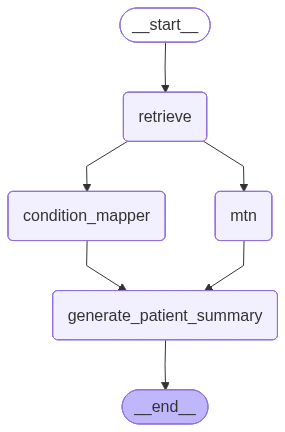

In [91]:
# Now lets build the Graph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# -------------------------------
# Building the graph
# -------------------------------
workflow = StateGraph(State)

# Add nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("mtn", mtn)
workflow.add_node("condition_mapper", condition_mapper)
workflow.add_node("generate_patient_summary", patient_summary)

# Flow
workflow.add_edge(START, "retrieve")

workflow.add_edge("retrieve", "mtn")
workflow.add_edge("retrieve", "condition_mapper")

workflow.add_edge("mtn", "generate_patient_summary")
workflow.add_edge("condition_mapper", "generate_patient_summary")

workflow.add_edge("generate_patient_summary", END)

# Compile
app = workflow.compile()

#view the graph
display(Image(app.get_graph().draw_mermaid_png()))


In [92]:
result = app.invoke(
    {
        "patient_report": patient_report_text,
        "retrieved_docs": [],        # will be filled by retrieve node
        "mtn_output": "",
        "condition_output": "",
        "patient_summary": ""
    }
)


In [93]:
print("\n===== Patient Friendly Summary =====\n")
print(result["patient_summary"])


===== Patient Friendly Summary =====

**Medical Report Summary for Lyubochka Svetka**

Here’s a simplified overview of your lab report:

- **Hemoglobin**: 14.5 g/dL (normal) – This means your blood is effectively carrying oxygen.
- **RBC Count**: 4.79 million cells/cmm (normal) – You have a healthy number of red blood cells.
- **WBC Count**: 10,570 cells/cmm (slightly high) – This may indicate your body is responding to an infection.
- **Platelet Count**: 150,000 cells/cmm (at the lower end of normal) – Important for blood clotting, and it’s good to keep an eye on this.
- **ESR**: 7 mm/hr (normal) – This shows no significant inflammation is present.
- **Blood Cell Appearance**: Normal shapes and sizes, with no signs of malaria.

Overall, your blood counts are mostly within normal limits, suggesting stable health. The slightly elevated white blood cell count may indicate a mild response to an infection or inflammation. 

It’s a good idea to discuss these results with your healthcare pr